# 05 - Final Load Preparation
## Retail Analytics | SectionB Group 3

This notebook prepares the cleaned dataset for machine learning:
- Drop irrelevant identifier columns
- Label-encode all categorical variables
- Standard-scale numerical features
- Validate zero nulls
- Perform 80/20 train/test split
- Save final CSVs to `data/processed/`


## KPI Calculations & Tableau Export

All KPI calculations use `df_kpi` — the original cleaned dataset in human-readable form (not encoded). This keeps the ML pipeline (`df`) cleanly separated from the analytics layer.


### a. Overall KPIs


In [1]:
from pathlib import Path
PROJECT_ROOT = Path('.').resolve().parent
INPUT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_dataset.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLEAU_READY_PATH = PROJECT_ROOT / 'data' / 'processed' / 'tableau_ready_data.csv'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load original cleaned data (before encoding) for KPI calculations
df_kpi = pd.read_csv(INPUT_PATH)
df_kpi['Date'] = pd.to_datetime(df_kpi['Date'])

total_revenue       = df_kpi['Total_Amount'].sum()
total_transactions  = df_kpi['Transaction_ID'].nunique()
total_customers     = df_kpi['Customer_ID'].nunique()
overall_aov         = df_kpi['Total_Amount'].mean()
avg_rating          = df_kpi['Ratings'].mean()

print('=' * 45)
print(f'  Total Revenue:            ₹{total_revenue:,.2f}')
print(f'  Total Transactions:        {total_transactions:,}')
print(f'  Unique Customers:          {total_customers:,}')
print(f'  Overall AOV:              ₹{overall_aov:,.2f}')
print(f'  Average Rating:            {avg_rating:.2f} / 5')
print('=' * 45)

  Total Revenue:            ₹412,922,905.96
  Total Transactions:        294,461
  Unique Customers:          86,766
  Overall AOV:              ₹1,367.27
  Average Rating:            3.16 / 5


### b. Revenue by Customer Segment


Total Revenue per Customer Segment (₹):
 Customer_Segment
Regular    2.001401e+08
New        1.246908e+08
Premium    8.776346e+07
Unknown    3.285013e+05
Name: Total_Amount, dtype: float64


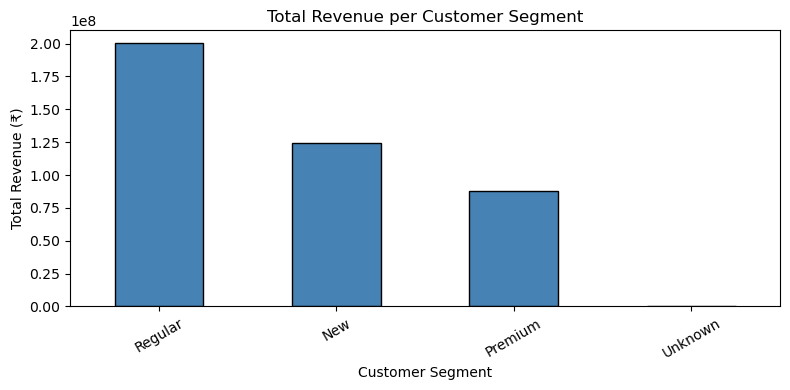

In [2]:
revenue_by_segment = df_kpi.groupby('Customer_Segment')['Total_Amount'].sum().sort_values(ascending=False)
print('Total Revenue per Customer Segment (₹):\n', revenue_by_segment)

plt.figure(figsize=(8, 4))
revenue_by_segment.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Total Revenue per Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_revenue_by_segment.png')
plt.show()


### c. AOV by Product Category


Average Order Value by Product Category (₹):
 Product_Category
Electronics    1369.395205
Clothing       1368.115656
Home Decor     1367.093604
Books          1366.606321
Grocery        1364.976167
Name: Total_Amount, dtype: float64


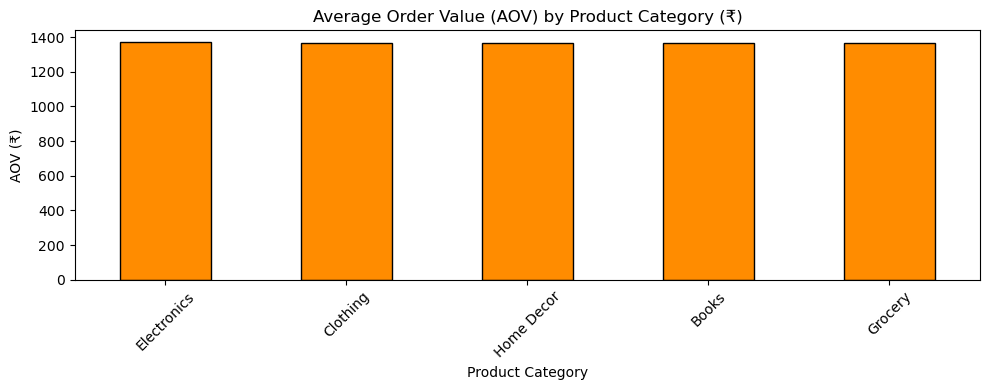

In [3]:
aov_by_category = df_kpi.groupby('Product_Category')['Total_Amount'].mean().sort_values(ascending=False)
print('Average Order Value by Product Category (₹):\n', aov_by_category)

plt.figure(figsize=(10, 4))
aov_by_category.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Average Order Value (AOV) by Product Category (₹)')
plt.xlabel('Product Category')
plt.ylabel('AOV (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_aov_by_category.png')
plt.show()


### d. Sales Contribution % by Product Category


Sales Contribution (%) by Product Category:
 Product_Category
Electronics    23.70
Grocery        22.08
Clothing       18.14
Books          18.08
Home Decor     18.00
Name: Total_Amount, dtype: float64


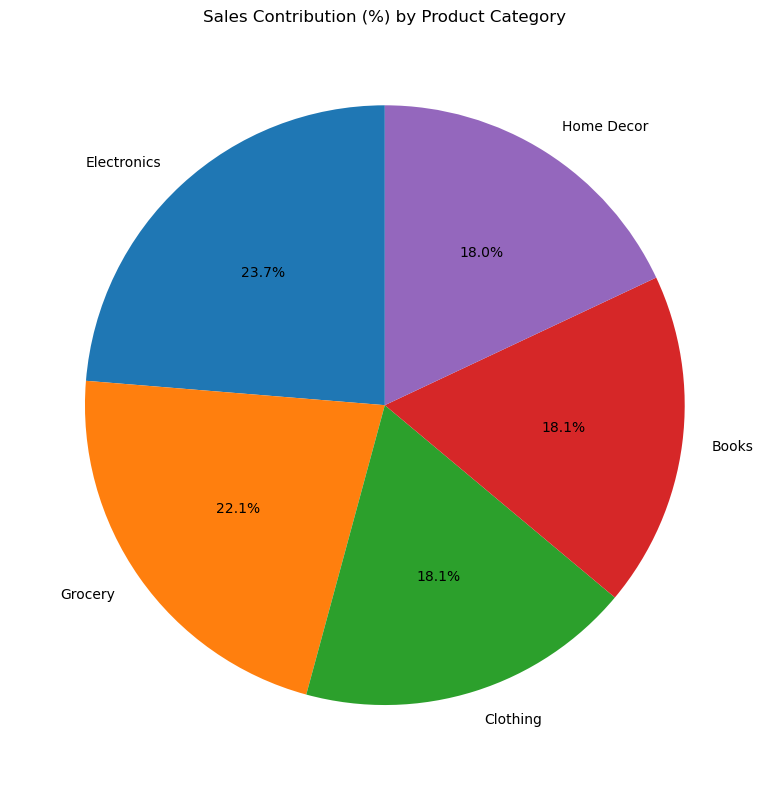

In [4]:
sales_pct = (df_kpi.groupby('Product_Category')['Total_Amount'].sum() / total_revenue * 100).sort_values(ascending=False)
print('Sales Contribution (%) by Product Category:\n', sales_pct.round(2))

plt.figure(figsize=(8, 8))
plt.pie(sales_pct.values, labels=sales_pct.index, autopct='%1.1f%%', startangle=90)
plt.title('Sales Contribution (%) by Product Category')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_sales_pct_category.png')
plt.show()


### e. Monthly Revenue Trend


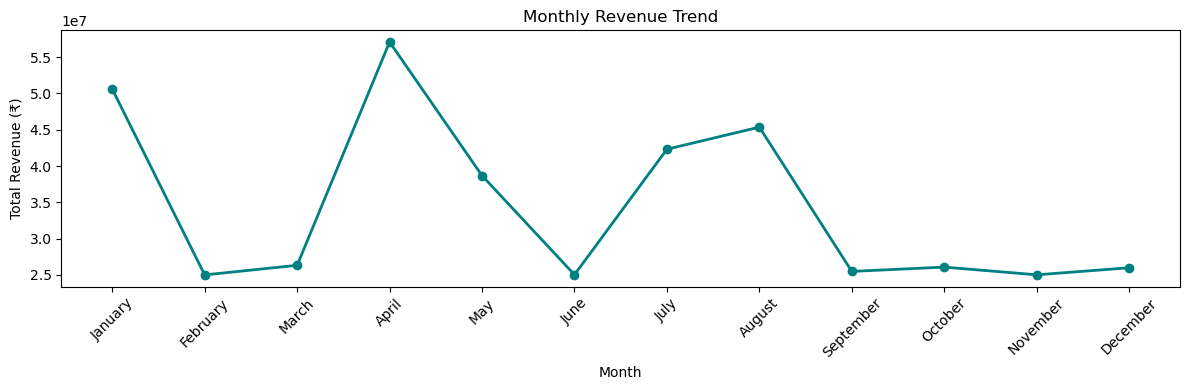

In [5]:
monthly_revenue = df_kpi.groupby('Month')['Total_Amount'].sum()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_revenue = monthly_revenue.reindex([m for m in month_order if m in monthly_revenue.index])

plt.figure(figsize=(12, 4))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', color='teal', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_monthly_trend.png')
plt.show()


### f. Revenue by Country (Top 10)


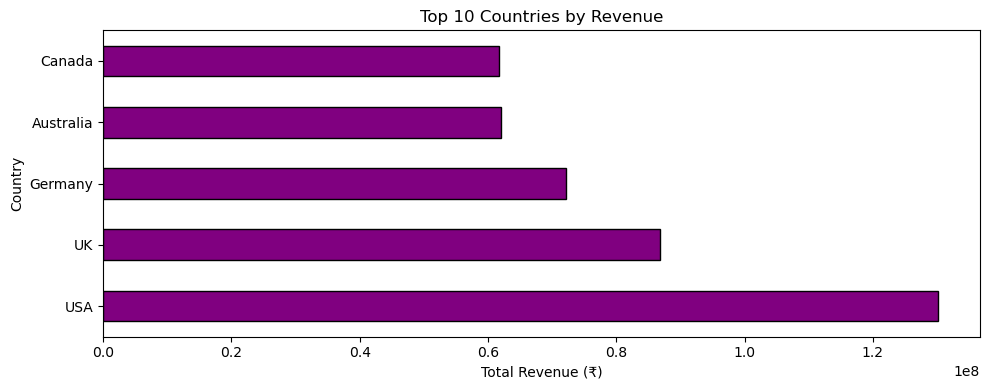

In [6]:
country_revenue = df_kpi.groupby('Country')['Total_Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
country_revenue.plot(kind='barh', color='purple', edgecolor='black')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (₹)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_revenue_by_country.png')
plt.show()


### g. Order Status Breakdown


Order Status Distribution (%):
 Order_Status
Delivered     43.19
Shipped       21.53
Processing    18.94
Pending       16.34
Name: proportion, dtype: float64


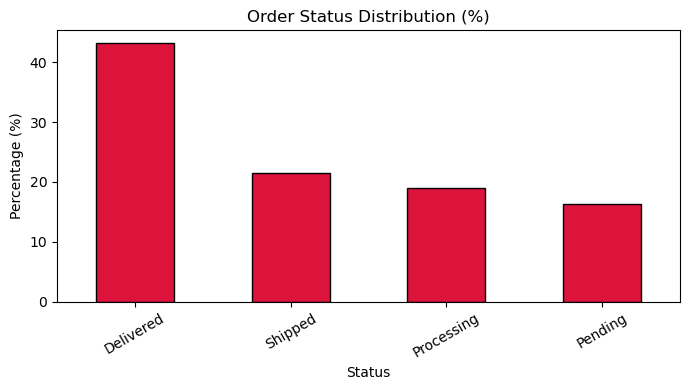

In [7]:
order_status_pct = df_kpi['Order_Status'].value_counts(normalize=True) * 100
print('Order Status Distribution (%):\n', order_status_pct.round(2))

plt.figure(figsize=(7, 4))
order_status_pct.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Order Status Distribution (%)')
plt.xlabel('Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_order_status.png')
plt.show()


### h. Average Rating by Product Category


Average Rating by Product Category:
 Product_Category
Electronics    3.27
Grocery        3.18
Books          3.11
Home Decor     3.11
Clothing       3.10
Name: Ratings, dtype: float64


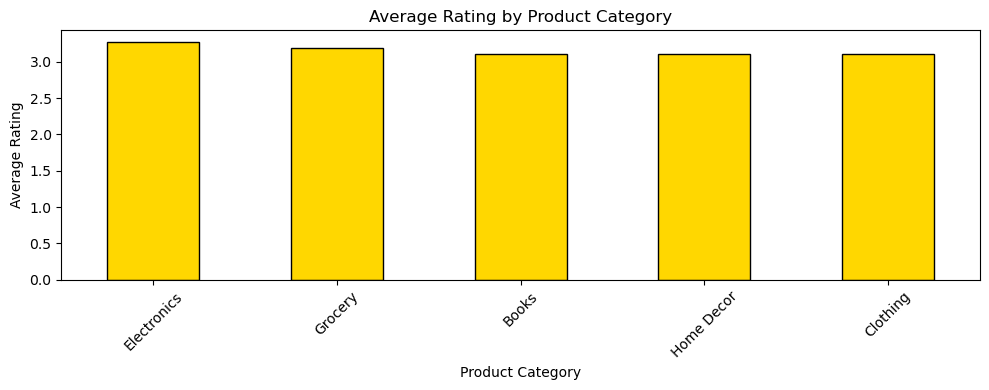

In [8]:
avg_rating_cat = df_kpi.groupby('Product_Category')['Ratings'].mean().sort_values(ascending=False)
print('Average Rating by Product Category:\n', avg_rating_cat.round(2))

plt.figure(figsize=(10, 4))
avg_rating_cat.plot(kind='bar', color='gold', edgecolor='black')
plt.title('Average Rating by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_avg_rating_category.png')
plt.show()


### i. Revenue by Payment Method


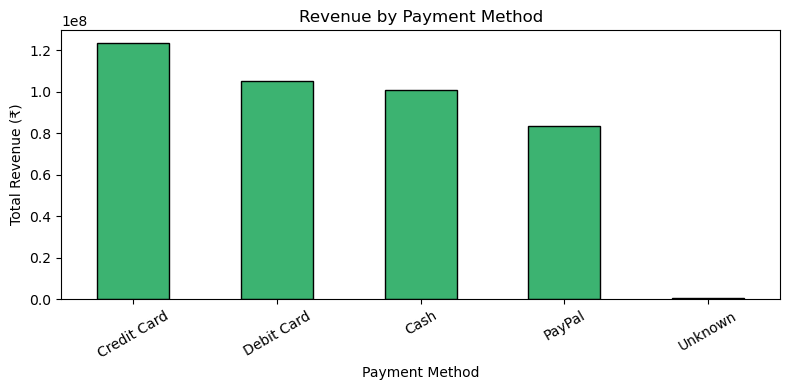

In [9]:
payment_revenue = df_kpi.groupby('Payment_Method')['Total_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
payment_revenue.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_revenue_by_payment.png')
plt.show()


### j. Weekend vs Weekday Revenue


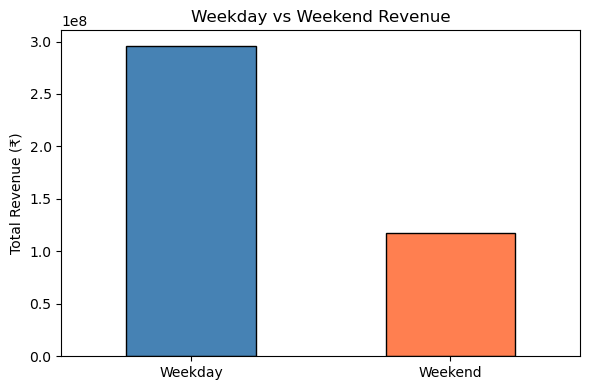

In [10]:
weekend_revenue = df_kpi.groupby('is_weekend')['Total_Amount'].sum()
weekend_revenue.index = ['Weekday', 'Weekend']

plt.figure(figsize=(6, 4))
weekend_revenue.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Weekday vs Weekend Revenue')
plt.ylabel('Total Revenue (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'kpi_weekend_vs_weekday.png')
plt.show()


### k. Save Tableau-Ready Dataset


In [11]:
# Save original cleaned data (human-readable, not encoded) for Tableau
df_kpi.to_csv(TABLEAU_READY_PATH, index=False)
print(f'✓ Tableau-ready dataset saved → {TABLEAU_READY_PATH}')
print(f'  Shape: {df_kpi.shape}')


✓ Tableau-ready dataset saved → /Users/bulbulagarwalla/SectionB_G3_RetailAnalytics/data/processed/tableau_ready_data.csv
  Shape: (302006, 35)


**KPI Insights:** These KPIs form the foundation of the retail dashboard. Revenue by segment identifies which customer groups drive the most value. AOV by category highlights premium product lines. Monthly trend reveals seasonal patterns. Country revenue guides geographic marketing spend. Order status and ratings flag operational and quality issues that, if resolved, directly recover lost revenue.
